effect size = 
alpha = 0.05
power = 1-beta = 0.80
sample size = what we want to find for each ROI

assumes a normal distribution of GMV per ROI

In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.power import FTestAnovaPower
from tqdm import tqdm

# --- 1. Load Data ---
path = "/home/gaia/Projects/legacy_data/legacy_pipe/data/processed/combined_df_with_weights_per_window.pkl"
combined_df = pd.read_pickle(path)

# CLEANING: Ensure no NaNs in critical columns before starting
combined_df = combined_df.dropna(subset=['ps_weight', 'volume_mm3', 'birth_year'])
# Ensure weights are positive (WLS fails on 0 or negative weights)
combined_df = combined_df[combined_df['ps_weight'] > 0]

age_windows = [20, 25, 30]
list_of_rois = list(range(1, 455))

# --- 2. Settings & Setup ---
target_power = 0.80
alpha = 0.05
k_predictors = 4 

pa = FTestAnovaPower()
parametric_power_results = []

# --- 3. Run Analysis ---
for age in age_windows:
    min_window, max_window = age, age + 5
    volumes_window = combined_df[
        (combined_df['age_in_years'] >= min_window) & 
        (combined_df['age_in_years'] < max_window)
    ].copy()
    
    if volumes_window.empty:
        continue

    print(f"--- Processing: Age {min_window}-{max_window} ---")

    for roi in tqdm(list_of_rois):
        roi_df = volumes_window[volumes_window['region_label'] == roi].copy()
        
        # Check for minimum sample size to avoid singular matrices
        if len(roi_df) < 10: 
            continue

        # A. Calculate Observed Effect Size (f2)
        model = smf.wls(
            'volume_mm3 ~ birth_year + C(sex) + tiv + age_in_years',
            data=roi_df,
            weights=roi_df['ps_weight']
        ).fit()
        
        r2 = max(0, model.rsquared) # Ensure r2 isn't negative
        f2 = r2 / (1 - r2) if r2 < 0.99 else 0.5 
        f2 = max(f2, 0.0001) # Use a tiny floor instead of 0.001

        # B. Calculate Kish's Effective Sample Size (ESS)
        # We add a tiny epsilon to the denominator to prevent division by zero
        w = roi_df['ps_weight'].values
        sum_w_sq = np.sum(w**2)
        
        if sum_w_sq > 0:
            ess = (np.sum(w)**2) / sum_w_sq
            design_effect = len(roi_df) / ess
        else:
            ess, design_effect = np.nan, np.nan

        # C. Solve for Required N
        req_raw_n = np.nan
        if not np.isnan(ess) and f2 > 0:
            try:
                # Solve for ESS
                req_ess = pa.solve_power(
                    effect_size=f2, 
                    alpha=alpha, 
                    power=target_power, 
                    k_groups=k_predictors
                )
                # Convert to Raw N
                req_raw_n = int(np.ceil(req_ess * design_effect))
            except:
                req_raw_n = np.nan # Keep as NaN if it literally won't converge

        parametric_power_results.append({
            'age_bin': f"({min_window}, {max_window}]",
            'roi': roi,
            'observed_f2': round(f2, 6),
            'design_effect': round(design_effect, 3) if not np.isnan(design_effect) else np.nan,
            'current_ess': round(ess, 2) if not np.isnan(ess) else np.nan,
            'required_n_for_80_power': req_raw_n
        })

# --- 4. Final Dataframe ---
parametric_df = pd.DataFrame(parametric_power_results)

# Final Check
print("\nColumn Null Counts:")
print(parametric_df.isnull().sum())

if not parametric_df.dropna(subset=['required_n_for_80_power']).empty:
    output_path = "/home/gaia/Projects/legacy_data/legacy_pipe/data/processed/parametric_power_results.csv"
    parametric_df.to_csv(output_path, index=False)
    print(f"✅ Success! Saved to {output_path}")
else:
    print("❌ Results are still coming up as NaN. Please check if 'ps_weight' contains valid numbers.")

--- Processing: Age 20-25 ---


100%|██████████| 454/454 [00:04<00:00, 107.53it/s]


--- Processing: Age 25-30 ---


100%|██████████| 454/454 [00:04<00:00, 110.33it/s]


--- Processing: Age 30-35 ---


100%|██████████| 454/454 [00:03<00:00, 128.28it/s]


Column Null Counts:
age_bin                    0
roi                        0
observed_f2                0
design_effect              0
current_ess                0
required_n_for_80_power    0
dtype: int64
✅ Success! Saved to /home/gaia/Projects/legacy_data/legacy_pipe/data/processed/parametric_power_results.csv


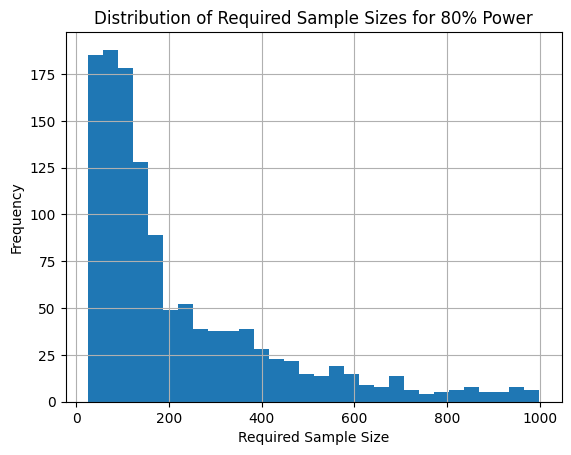

In [ ]:
import matplotlib.pyplot as plt 


# plot a histogram of required N per age window
parametric_df['required_n_for_80_power'].hist(bins=30)
plt.xlabel('Required Sample Size')
plt.ylabel('Frequency')
plt.title('Distribution of Required Sample Sizes for 80% Power')
plt.show()

In [ ]:
print(f"median required n for 80% power: {parametric_df['required_n_for_80_power'].median()}")
print(f"mean required n for 80% power: {parametric_df['required_n_for_80_power'].mean()}")
print(f"standard deviation required n for 80% power: {parametric_df['required_n_for_80_power'].std()}")

median required n for 80% power: 156.0
mean required n for 80% power: 457.16079295154185
standard deviation required n for 80% power: 1075.4324891805015
